In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nphantawee/pump-sensor-data")

print("Path to dataset files:", path)

100%|██████████| 37.1M/37.1M [00:03<00:00, 11.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nphantawee/pump-sensor-data/versions/1


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import pandas as pd
df =  pd.read_csv(os.path.join(path, "sensor.csv"))

In [5]:
df.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [6]:
df = df.drop(columns=['Unnamed: 0'])


In [7]:
len(df)

220320

In [8]:
rows_with_zero_or_nan = df.applymap(lambda x: pd.isna(x) ).any(axis=1)  # adding this not changing anything 'or x == 0'
count = rows_with_zero_or_nan.sum()
print(f"Number of rows with at least one 0 or NaN value: {count}")

/tmp/ipykernel_567/2342891805.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  rows_with_zero_or_nan = df.applymap(lambda x: pd.isna(x) ).any(axis=1)  # adding this not changing anything 'or x == 0'


Number of rows with at least one 0 or NaN value: 220320


In [9]:
df.head()

,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [10]:
print(df.isnull().sum())

timestamp              0
sensor_00          10208
sensor_01            369
sensor_02             19
sensor_03             19
sensor_04             19
sensor_05             19
sensor_06           4798
sensor_07           5451
sensor_08           5107
sensor_09           4595
sensor_10             19
sensor_11             19
sensor_12             19
sensor_13             19
sensor_14             21
sensor_15         220320
sensor_16             31
sensor_17             46
sensor_18             46
sensor_19             16
sensor_20             16
sensor_21             16
sensor_22             41
sensor_23             16
sensor_24             16
sensor_25             36
sensor_26             20
sensor_27             16
sensor_28             16
sensor_29             72
sensor_30            261
sensor_31             16
sensor_32             68
sensor_33             16
sensor_34             16
sensor_35             16
sensor_36             16
sensor_37             16
sensor_38             27


In [11]:
# Drop sensors with excessive missing values
sensors_to_drop = ['sensor_15', 'sensor_50']
df = df.drop(columns=sensors_to_drop)


# Maybe KNN for filling data could be better maybe later will check

In [12]:
sensor_cols = df.columns[df.isnull().any()].tolist()

print("Columns with at least one NaN value:")
print(sensor_cols)

Columns with at least one NaN value:
['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_51']


In [13]:
# Linear interpolation
df[sensor_cols] = df[sensor_cols].interpolate(method='linear')

# If any remaining NaNs, use forward/backward fill
df[sensor_cols] = df[sensor_cols].fillna(method='ffill')
df[sensor_cols] = df[sensor_cols].fillna(method='bfill')
# Verify no missing values remain
print(df[sensor_cols].isnull().sum())

/tmp/ipykernel_567/784687372.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[sensor_cols] = df[sensor_cols].fillna(method='ffill')
/tmp/ipykernel_567/784687372.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[sensor_cols] = df[sensor_cols].fillna(method='bfill')


sensor_00    0
sensor_01    0
sensor_02    0
sensor_03    0
sensor_04    0
sensor_05    0
sensor_06    0
sensor_07    0
sensor_08    0
sensor_09    0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
sensor_22    0
sensor_23    0
sensor_24    0
sensor_25    0
sensor_26    0
sensor_27    0
sensor_28    0
sensor_29    0
sensor_30    0
sensor_31    0
sensor_32    0
sensor_33    0
sensor_34    0
sensor_35    0
sensor_36    0
sensor_37    0
sensor_38    0
sensor_39    0
sensor_40    0
sensor_41    0
sensor_42    0
sensor_43    0
sensor_44    0
sensor_45    0
sensor_46    0
sensor_47    0
sensor_48    0
sensor_49    0
sensor_51    0
dtype: int64


In [14]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Encode machine_status if necessary
df['machine_status'] = df['machine_status'].map({'NORMAL': 0, 'BROKEN': 1, 'RECOVERING': 2})


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 52 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   timestamp       220320 non-null  datetime64[ns]
 1   sensor_00       220320 non-null  float64       
 2   sensor_01       220320 non-null  float64       
 3   sensor_02       220320 non-null  float64       
 4   sensor_03       220320 non-null  float64       
 5   sensor_04       220320 non-null  float64       
 6   sensor_05       220320 non-null  float64       
 7   sensor_06       220320 non-null  float64       
 8   sensor_07       220320 non-null  float64       
 9   sensor_08       220320 non-null  float64       
 10  sensor_09       220320 non-null  float64       
 11  sensor_10       220320 non-null  float64       
 12  sensor_11       220320 non-null  float64       
 13  sensor_12       220320 non-null  float64       
 14  sensor_13       220320 non-null  flo

# I will scale the shit out of my sensors

In [16]:
from sklearn.preprocessing import StandardScaler

# Select sensor columns
sensor_cols = [col for col in df.columns if 'sensor_' in col]

# Scale sensor data using StandardScaler
scaler = StandardScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])


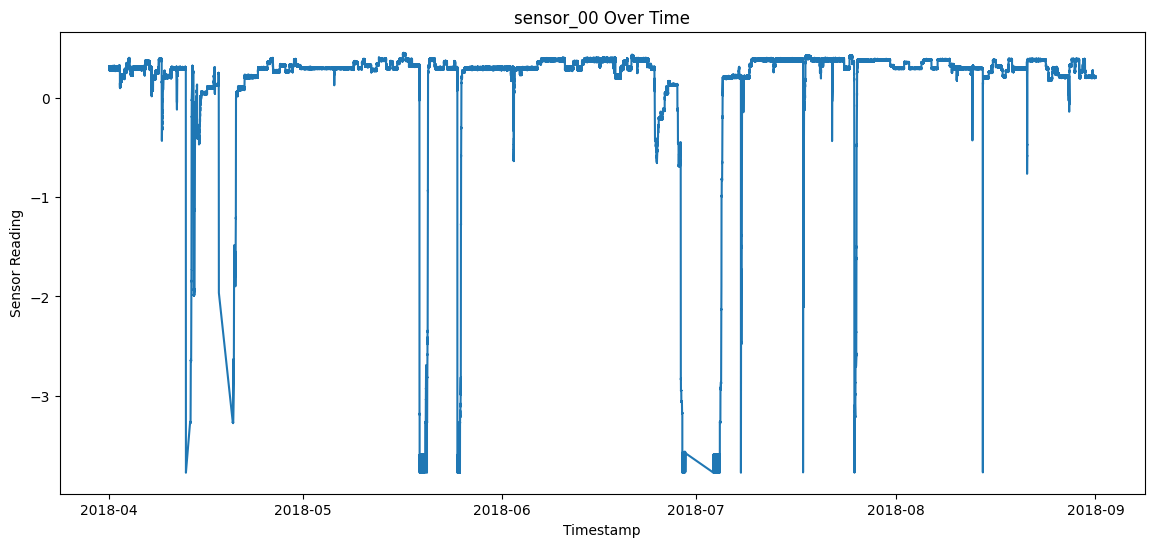

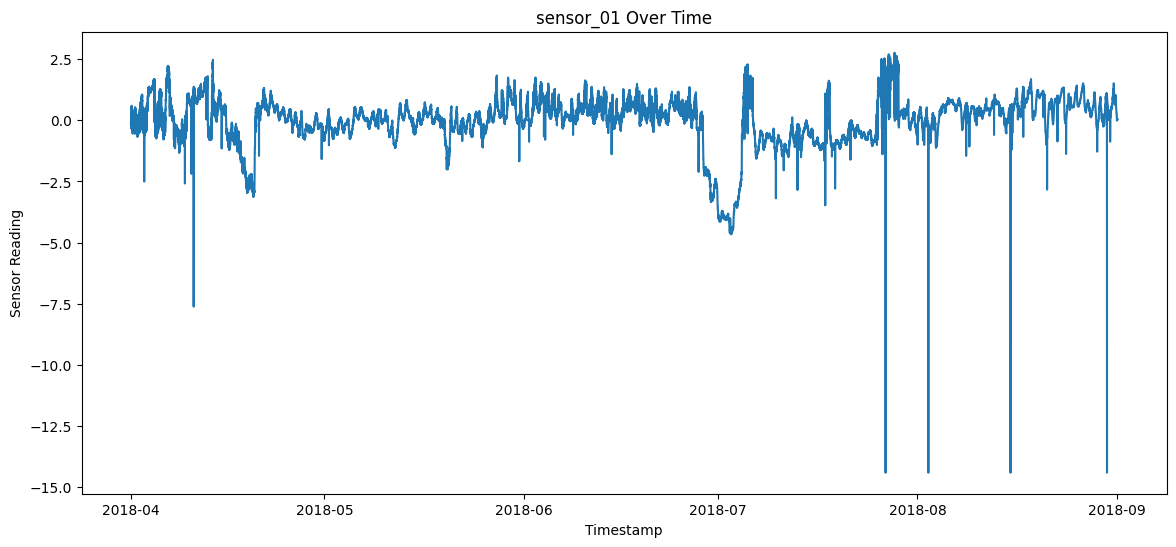

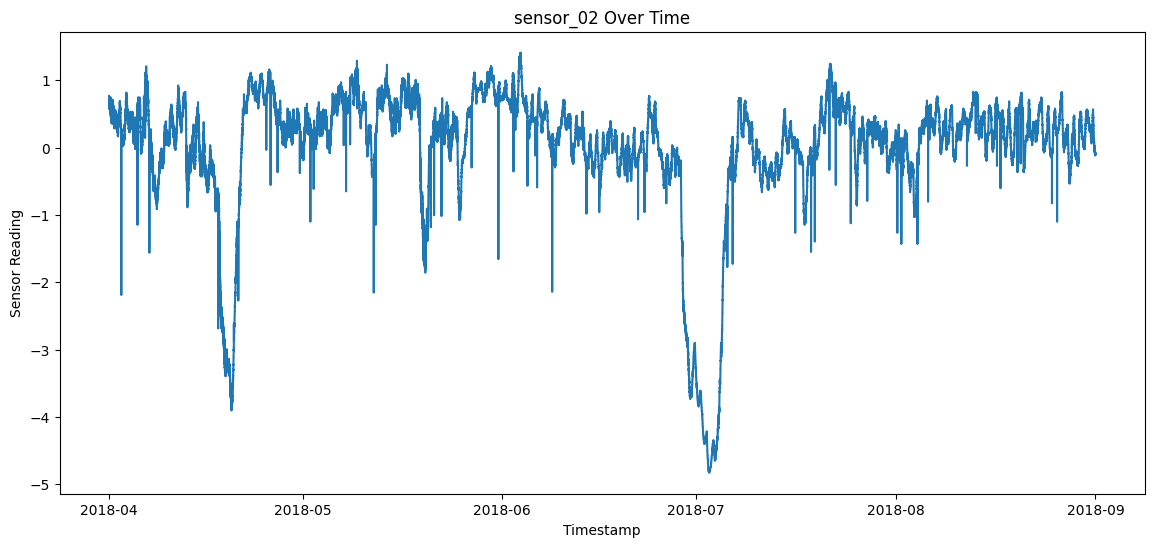

In [17]:
import matplotlib.pyplot as plt

# Plot sensor readings over time for a few sensors
for col in sensor_cols[:3]:
    plt.figure(figsize=(14, 6))
    plt.plot(df['timestamp'], df[col])
    plt.title(f'{col} Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Sensor Reading')
    plt.show()


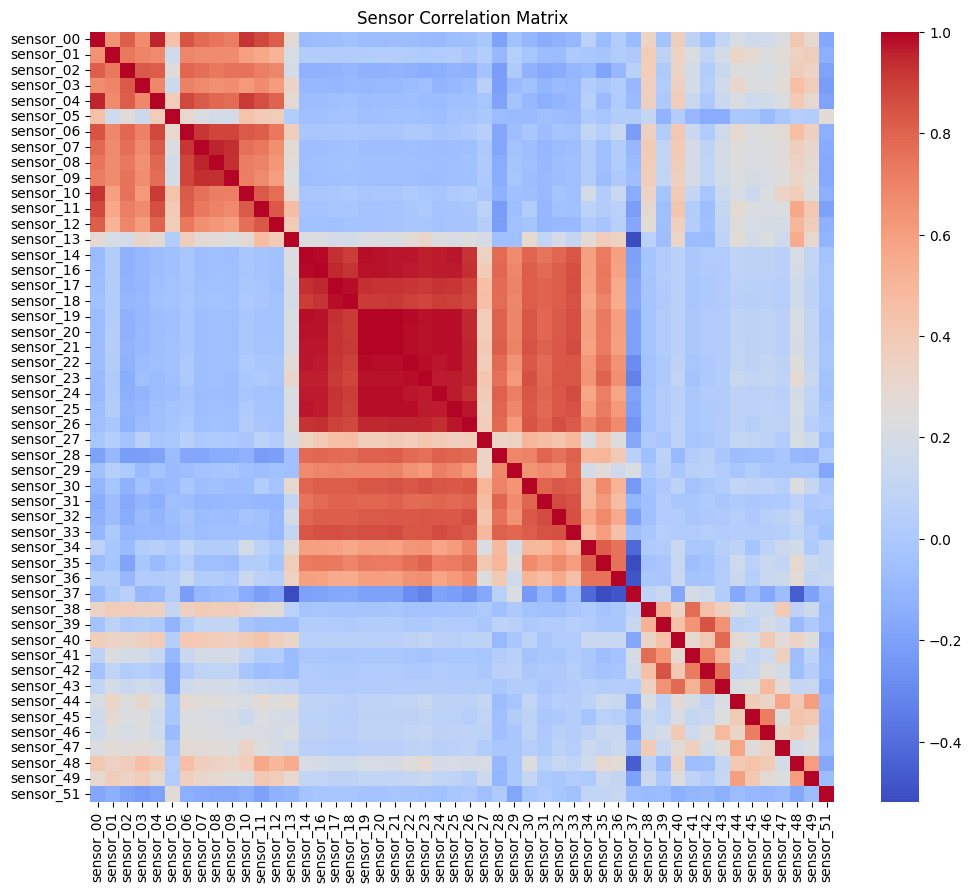

In [18]:
import seaborn as sns

# Compute correlation matrix
corr_matrix = df[sensor_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Sensor Correlation Matrix')
plt.show()


In [19]:
# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month


In [20]:
from sklearn.decomposition import PCA

# Apply PCA to sensor data
pca = PCA(n_components=0.99)  # Retain 95% of variance
sensor_data_pca = pca.fit_transform(df[sensor_cols])

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f'Number of components selected: {pca.n_components_}')
print(f'Explained variance ratio: {sum(explained_variance)}')


Number of components selected: 34
Explained variance ratio: 0.990904489301806


In [21]:
# Reconstruct sensor data from PCA components
sensor_data_reconstructed = pca.inverse_transform(sensor_data_pca)

# Calculate reconstruction error
reconstruction_error = ((df[sensor_cols] - sensor_data_reconstructed) ** 2).mean(axis=1)

# Add reconstruction error to DataFrame
df['reconstruction_error'] = reconstruction_error

# Set anomaly threshold (e.g., 95th percentile)
threshold = df['reconstruction_error'].quantile(0.999)

# Flag anomalies
df['anomaly'] = df['reconstruction_error'] > threshold


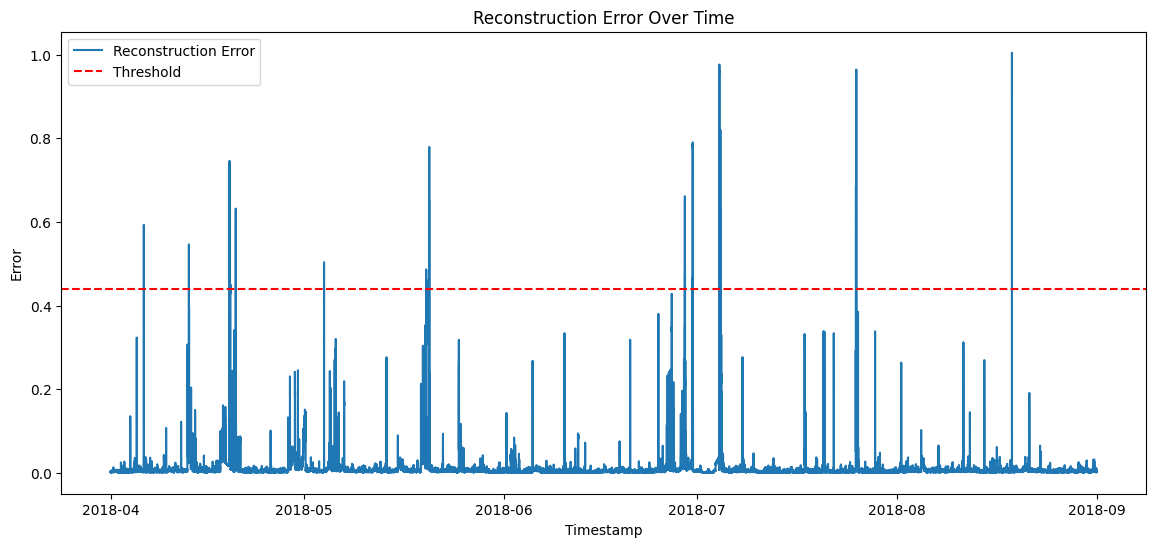

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(df['timestamp'], df['reconstruction_error'], label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title('Reconstruction Error Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Error')
plt.legend()
plt.show()


In [23]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = len(sensor_cols)
encoding_dim = int(input_dim / 2)

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation='relu')(input_layer)
decoder = Dense(input_dim, activation='sigmoid')(encoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,575 (10.06 KB)

 Trainable params: 2,575 (10.06 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Prepare data
X = df[sensor_cols].values

# Train model
autoencoder.fit(X, X, epochs=50, batch_size=64, shuffle=True, validation_split=0.1)


Epoch 1/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.9246 - val_loss: 0.2967
Epoch 2/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.8327 - val_loss: 0.2843
Epoch 3/50
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.8242 - val_loss: 0.2819
Epoch 4/50
1797/3099 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8448

KeyboardInterrupt: 

In [ ]:
# Reconstruct data
X_pred = autoencoder.predict(X)

# Calculate reconstruction error
mse = np.mean(np.power(X - X_pred, 2), axis=1)
df['reconstruction_error'] = mse

# Set threshold
threshold = np.percentile(mse, 99.9)
df['anomaly'] = df['reconstruction_error'] > threshold


6885/6885 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


In [ ]:
df['anomaly'].value_counts()

,count
anomaly,
False,220099
True,221


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df['timestamp'], df['reconstruction_error'], label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title('Reconstruction Error Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Error')
plt.legend()
plt.show()